# Prototype

## Channel Model – Key Relations

$th(x) = gpc \left( 1 - \exp(-c Q(x) t_p) \right)$  

$Q(x) = Q_0 \exp(-x/x_s)$  

$x_s \propto \sqrt{T/p_A}$

In [15]:
import torch
import torch.nn as nn

from torchdiffeq import odeint
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Channel Profile

In [16]:
N0 = 6.22*10**23
k = 1.38*10**-23 # Boltzmann constant
R = 8.314 # J/K.mol

In [17]:
# #may be better fitting the 'd' values
# def d_estimate(MA, rho):
#     #rho here is the fluid/solid density of the molecule
#     return 2* np.pow(3*MA/(4*np.pi*rho*N0), 1/3)

# def za(da, db, MA, MB, pA, pB):
#     #find collision rate of a; (A+B) collisions and A+A collisions
#     #molecular diameter, molar mass, partial pressure
#     return (np.pi/4*((da+db)**2)*np.sqrt(8*R*T/np.pi*(1/MA + 1/MB)) * pB + np.pi * da**2 * np.sqrt(16*R*T/(np.pi*MA))*pA) /(R*T)

# def Deff(da, db, MA, MB, pA, pB):
#     z_a = za(da, db, MA, MB, pA, pB)
#     va = np.sqrt(8*R*T/(np.pi * MA))
#     Da = 3*np.pi/16 * va**2/z_a
#     Dkn = h*np.sqrt(8*R*T/(9*np.pi*MA))
#     Deff = 1/(1/Da + 1/Dkn)
#     return Deff

In [18]:
class channelModel():

    def __init__(self):

        self.M = 101.96/1000 # kg/mol (molar mass of formula unit of film)
        self.rho = 3.99*1000 #density of film material

        self.b_film = 2 # number of metal atoms in the formula unit for the film
        self.b_a = 1 # number of metal atoms in the reactant, i.e. TMA
        self.c = 0.01 # c = sticking probability
        #self.Pd = 0 # Pd = Desorption probability
        self.da = 591e-12 #tma #d_estimate()
        self.db = 418e-12 #water #d_estimate()
        # Molar Mass
        self.MA = 72.09e-3 #kg/mol
        self.MB = 18e-3

        # Channel Geometry
        self.H = 0.2e-6
        self.W = 0.1e-3

        self.gpc = 106 * 10**-12 # gpc (m)
        self.K = 100 # equilibrium constant for langmuir model
        # or K = cQ/(qP_d)
        # But they seem to generally give K as its own value
        # c is used for calculating the delimiter instead

        self.T = 300 + 273 # Temperature
        self.t_p = 0.1 #pulse time

        self.pA = 100 #*1e-3 # Partial Pressure of reactant A (limiting diffusion)
        #self.pA0 = self.pA
        self.pB = 300 # partial pressure of reactant B

    def calc_hydro_diameter(self):
        self.h = 2/(1/self.H + 1/self.W)
    def calc_adsorption_density(self):
        self.q = (self.b_film/self.b_a) * (self.rho*self.gpc/self.M) * N0 #TMA q (adsorption density)
    def collision_rate(self):
        self.Q = N0/np.sqrt(2*np.pi* self.M * R * self.T)# Q: collision rate at unit pressure

    def calc_za(self):
        #find collision rate of a; (A+B) collisions and A+A collisions
        #molecular diameter, molar mass, partial pressure
        self.za = (np.pi/4*((self.da+self.db)**2)*np.sqrt(8*R*self.T/np.pi*(1/self.MA + 1/self.MB)) * self.pB + \
                   np.pi * self.da**2 * np.sqrt(16*R*self.T/(np.pi*self.MA))*self.pA) /(R*self.T)
    def calc_Deff(self):
        z_a = self.za #(self.da, self.db, self.MA, self.MB, self.pA, self.pB)
        va = np.sqrt(8*R*self.T/(np.pi * self.MA))
        Da = 3*np.pi/16 * va**2/z_a
        Dkn = self.h*np.sqrt(8*R*self.T/(9*np.pi*self.MA))
        self.Deff = 1/(1/Da + 1/Dkn)

    def approx(self, x, last_theta):

        D = self.pA*self.Deff*self.H/(self.q*k*self.T*(1-np.log(self.K*self.pA+1)/(self.K*self.pA)))
        xs = np.sqrt(D*self.t_p)
        delim = np.sqrt((self.h*N0*self.Deff)/(4*R*self.T*self.c*self.Q))
        xt = xs-delim #np.max(0.0, xs-delim)
        if xt < 0:
            xt = 0
        pt = self.pA * (1-xt/xs)
        pA = self.pA * (1-x/xs)
        pA[x>xt] = pt*np.exp(-(x[x>xt]-xt)/(xs-xt))

        theta = (self.K*pA)/(1+self.K*pA)

        next_theta = last_theta + theta

        thickness = self.gpc*next_theta

        #print('xt: ', xt)

        return thickness, next_theta, {'theta':theta, 'pA': pA}

    def run(self, steps, initial_x):

        results = []#pd.DataFrame()

        #Assuming no temperature change, these don't need recalculation
        self.collision_rate()
        self.calc_adsorption_density()
        self.calc_za()
        last_theta = initial_x.copy()

        original_H = self.H

        for step in range(steps):
            self.calc_hydro_diameter()
            self.calc_Deff()
            thickness, last_theta, intermediates = self.approx(x, last_theta)
            results.append(pd.DataFrame({'thickness': thickness} | intermediates))
            self.H = self.H - 2 * self.gpc

        self.H = original_H

        results = pd.concat(results, keys=range(steps))
        return results




In [19]:
model = channelModel()
#model.pA *= 2
model.t_p*=10
model.H = 0.5* 0.2e-6
model.W = 1000*0.2e-6

In [20]:
x = np.linspace(0, 200e-6, 100)
result = model.run(100, x)

In [21]:
#result#['thickness'].values


In [22]:
# plt.plot(x, result['thickness'][19])
# plt.plot(x, result['thickness'][39])
# plt.plot(x, result['thickness'][59])
# plt.plot(x, result['thickness'][79])
# plt.plot(x, result['thickness'][99])

# plt.plot(x, model.H-result['thickness'][19])
# plt.plot(x, model.H-result['thickness'][39])
# plt.plot(x, model.H-result['thickness'][59])
# plt.plot(x, model.H-result['thickness'][79])
# plt.plot(x, model.H-result['thickness'][99])
# plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

Text(0, 0.5, 'channel geometry')

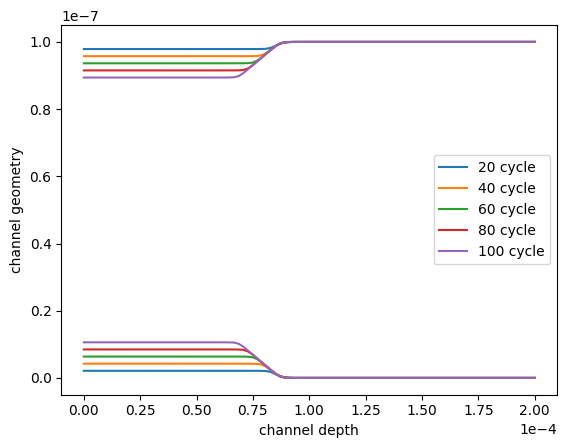

In [23]:
for cycle in [20, 40, 60, 80, 100]:
    l1 = plt.plot(x, result['thickness'][cycle-1], label= f'{cycle} cycle')
    plt.plot(x, model.H-result['thickness'][cycle-1], color=l1[0].get_color())

plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend()
plt.xlabel('channel depth')
plt.ylabel('channel geometry')

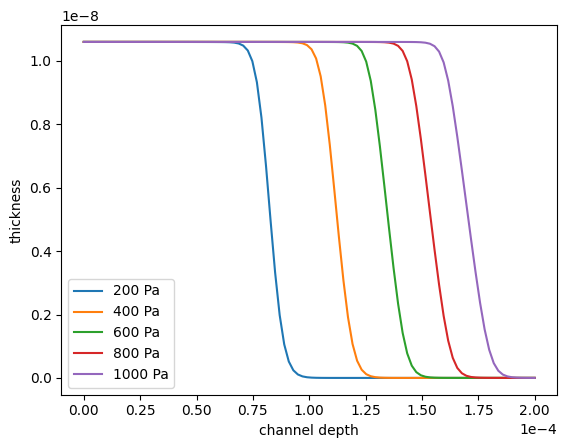

In [24]:

for pressure in range(200, 1200, 200):
    model = channelModel()
    model.pA = pressure
    x = np.linspace(0, 200e-6, 100)
    result = model.run(100, x)
    plt.plot(x, result['thickness'][99], label=f'{pressure} Pa')
plt.legend()
plt.ylabel('thickness')
plt.xlabel('channel depth')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

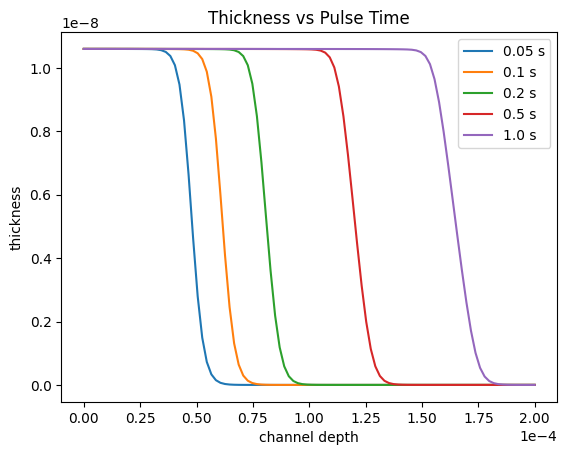

In [25]:
import numpy as np
import matplotlib.pyplot as plt

for tp in [0.05, 0.1, 0.2, 0.5, 1.0]:

    model = channelModel()
    model.t_p = tp   # 🔴 pulse time 변경

    x = np.linspace(0, 200e-6, 100)

    result = model.run(100, x)

    plt.plot(x, result['thickness'][99], label=f'{tp} s')

plt.legend()
plt.ylabel('thickness')
plt.xlabel('channel depth')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.title('Thickness vs Pulse Time')
plt.show()

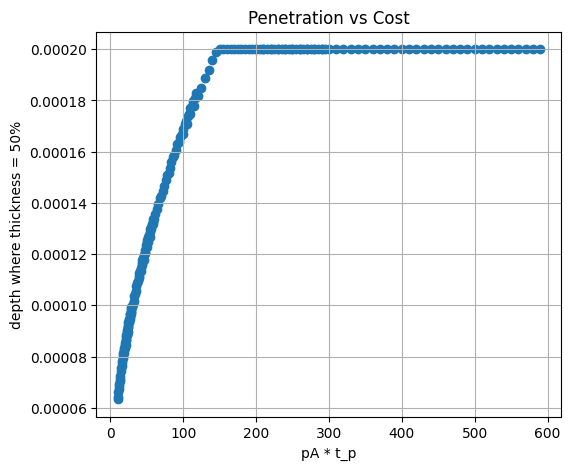

In [36]:
import numpy as np
import matplotlib.pyplot as plt

tp_list = [0.05, 0.1, 0.2, 0.5, 1.0]
p_list = range(200, 600, 10)

x = np.linspace(0, 200e-6, 200)

x_half_list = []
cost_list = []

for tp in tp_list:
    for p in p_list:

        model = channelModel()
        model.t_p = tp
        model.pA = p

        result = model.run(100, x)
        th = result['thickness'][99].values  # numpy array

        # 🔴 normalize (입구 기준)
        th_norm = th / th[0]

        # 🔴 0.5 되는 지점 찾기
        idx = np.where(th_norm <= 0.5)[0]

        if len(idx) == 0:
            x_half = x[-1]  # 끝까지 유지되면 max depth
        else:
            x_half = x[idx[0]]

        x_half_list.append(x_half)
        cost_list.append(p * tp)

# 🔥 plot
plt.figure(figsize=(6,5))
plt.scatter(cost_list, x_half_list)

plt.xlabel('pA * t_p')
plt.ylabel('depth where thickness = 50%')
plt.title('Penetration vs Cost')
plt.grid()

plt.show()

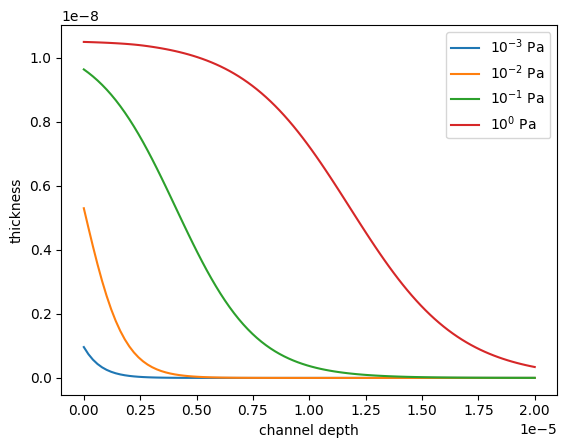

In [26]:

for pressure in range(-3, 1):
    model = channelModel()
    model.pA = 10**(pressure)
    x = np.linspace(0, 20e-6, 100)
    result = model.run(100, x)
    plt.plot(x, result['thickness'][99], label='$10^{'+f'{pressure}'+'}$ Pa')
plt.legend()
plt.ylabel('thickness')
plt.xlabel('channel depth')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

Text(0.5, 0, 'channel depth')

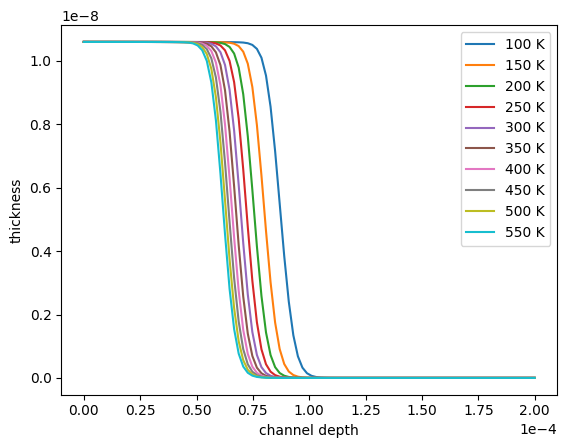

In [27]:

for temperature in range(100, 600, 50):
    model = channelModel()
    model.T = temperature
    x = np.linspace(0, 200e-6, 100)
    result = model.run(100, x)
    plt.plot(x, result['thickness'][99], label=f'{temperature} K')
plt.legend()
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ylabel('thickness')
plt.xlabel('channel depth')

Text(0, 0.5, 'pressure')

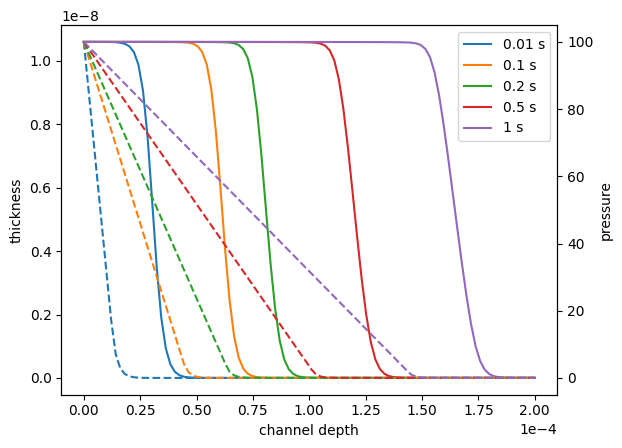

In [28]:
ax1 = plt.gca()
ax2 = ax1.twinx()

for time in [.01, .1, .2, .5, 1]:
    model = channelModel()
    model.t_p = time
    x = np.linspace(0, 200e-6, 100)
    result = model.run(100, x)
    p1 = ax1.plot(x, result['thickness'][99], label=f'{time} s')
    ax2.plot(x, result['pA'][99], color = p1[0].get_color(), linestyle='--')
ax1.legend()
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax1.set_ylabel('thickness')
ax1.set_xlabel('channel depth')
ax2.set_ylabel('pressure')

Text(0.5, 0, 'channel depth')

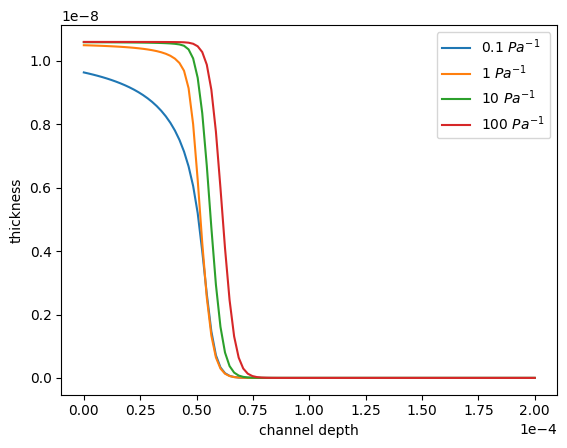

In [29]:

for ads_const in [.1, 1, 10, 100]:
    model = channelModel()
    model.K = ads_const
    x = np.linspace(0, 200e-6, 100)
    result = model.run(100, x)
    plt.plot(x, result['thickness'][99], label=f'{ads_const} '+'$Pa^{-1}$')
plt.legend()
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ylabel('thickness')
plt.xlabel('channel depth')